<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS1: Síntesis y operaciones de señales

## Estudiante: Mercedes López Gil Dillon


En el siguiente trabajo, buscamos generar señales de distintas maneras, logrando entender cómo funciona y para qué sirven herramientas como la convolución, la modulación, cómo podemos generar distintos tipos de señales como pulsos, deltas, etc. y cómo trabajar con estas.

### Ejercicio 1

El objetivo de este ejercicio es crear un codigo que nos permita generar y modificar distintos tipos de señales en el siguiente orden:
- Una señal sinusoidal de 2 KHz.
- Esta misma señal amplificada 3 dB y desfasada en π/2.
- La misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.
- La misma señal con efecto de saturación al 75% de su amplitud.
- Una señal cuadrada de 4KHz.
- Un pulso rectangular de 10ms.

In [134]:
import numpy as np
import matplotlib.pyplot as plt

#Defino mi función seno que usaré para crear las distintas funciones
def mi_funcion_sen ( vmax , dc , f0 , ph, n , fs):
    tt = np.linspace(0, (n-1)*ts, n)
    xx = dc + vmax * np.sin(2 * np.pi * f0 * tt + ph)
    return tt, xx

***Inciso 1***

En el primer ejercicio, buscamos crear una función senoidal cuya frecuencia sea de 2000Hz:

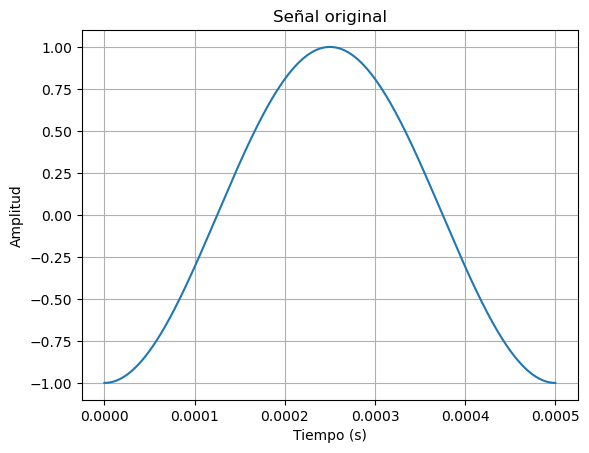

In [135]:
vmax= 1
dc=0
f0=2000
ph= - (np.pi/2)
n= 5000
fs= 10000000 #Es tan alto por la señal que armaremos en el inciso 3
ts= 1/fs

tt, xx = mi_funcion_sen( vmax , dc , f0 , ph, n , fs)

plt.plot(tt, xx)
plt.title("Señal original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

In [136]:
print('Período: ', 1/f0) #En la consigna no aclara si poner período de muestreo o período de la función por lo que pongo ambos
print('Período de muestreo: ', 1/fs)
print('Número de muestras: ', n)
print('Potencia de la señal: ', (vmax**2)/2)

Período:  0.0005
Período de muestreo:  1e-07
Número de muestras:  5000
Potencia de la señal:  0.5


***Inciso 2***

Ahora debemos defasar esta señal por pi/2 y ampliarla por 3dB.

In [137]:
vmax2= np.sqrt(2) * vmax #Al estar trabajando en tensión, para amplificar por 3dB debo multiplicar la amplitud por raiz de 2.
dc2=dc
f02= f0
ph2= ph + np.pi/2 #Defasamos la señal
n2= n
fs2= fs
ts2= 1/fs2

tt2, xx2 = mi_funcion_sen( vmax2 , dc , f02 , ph2, n2 , fs2)

In [138]:
print('Período: ', 1/f02)
print('Período de muestreo: ', 1/fs2)
print('Número de muestras: ', n2)
print('Potencia de la señal: ', (vmax2**2)/2)

Período:  0.0005
Período de muestreo:  1e-07
Número de muestras:  5000
Potencia de la señal:  1.0000000000000002


A continuación podemos ver ambas señales juntas lo que nos permite comparar los cambios:

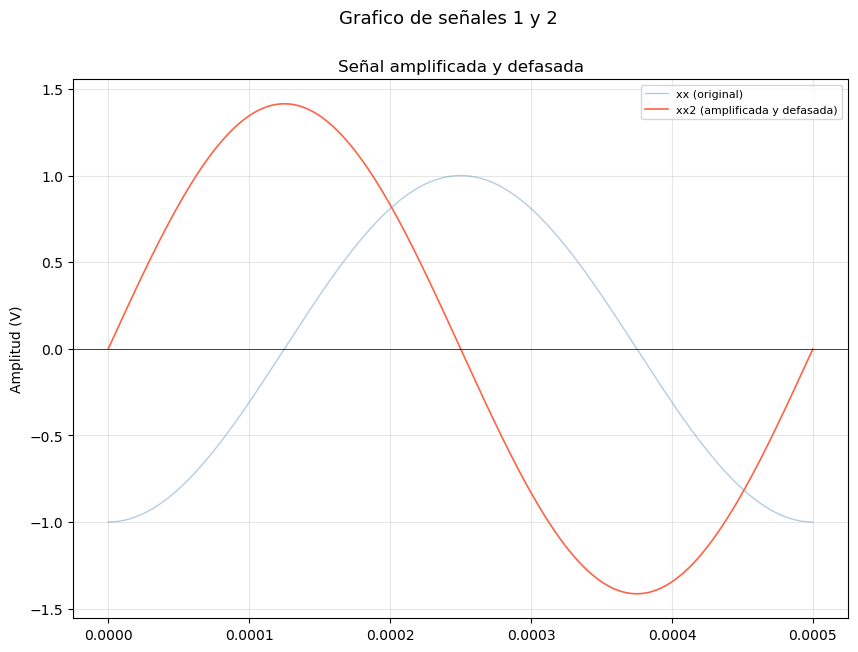

In [139]:
'Acá podemos ver las dos señales juntas'

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Grafico de señales 1 y 2', fontsize=13)


ax1.plot(tt, xx,  color='steelblue', linewidth=1,   alpha=0.4, label='xx (original)')
ax1.plot(tt2, xx2, color='tomato',    linewidth=1.2, label='xx2 (amplificada y defasada)')
ax1.set_ylabel('Amplitud (V)')
ax1.set_title('Señal amplificada y defasada')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)

Como podemos observar, la señal original y la que acabamos de generar difieren en amplitud (una tiene una amplitud de 1 y la segunda, tal como esperábamos, tiene una amplitud de raiz de 2 ~ 1,41.

***Inciso 3***

Para el ejercicio 3, debemos generar una señal que tenga los mismos parámetros que los que tenemos en la señal original, cambiando únicamente la frecuencia (la señal original tiene f0 = 2000Hz y la que vamos a generar tiene f03 = 1000kHz).

In [140]:
'Creamos una tercer función, identica a f2 pero con la mitad de la frecuencia'

f03= 1000000

_ , xx3 = mi_funcion_sen(vmax, dc, f03, ph, n, fs)
tt3 = tt2

A continuación, generamos un grafico con ambas señales para poder verlas y compararlas entre sí.

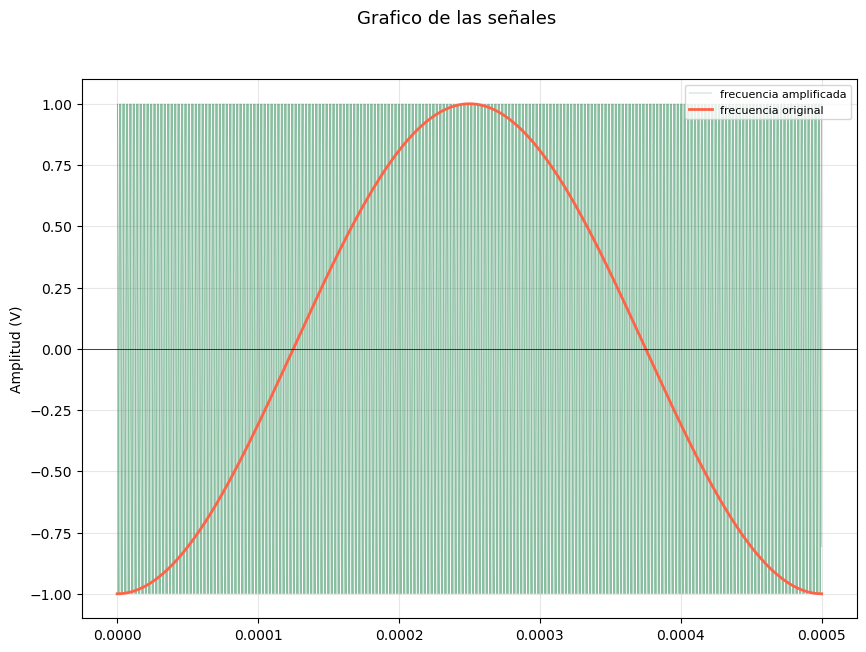

In [141]:
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Grafico de las señales', fontsize=13)

ax1.plot(tt3, xx3, color='seagreen',    linewidth=0.2, label='frecuencia amplificada')
ax1.plot(tt, xx, color='tomato',    linewidth=2, label='frecuencia original')
ax1.set_ylabel('Amplitud (V)')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)

Como podemos ver, debido a la tan alta frecuencia que tiene la última funcion en comparación con la original, los períodos están tan cercanos unos de otros que pareciera que se ve un rectánngulo en lugar de una función.

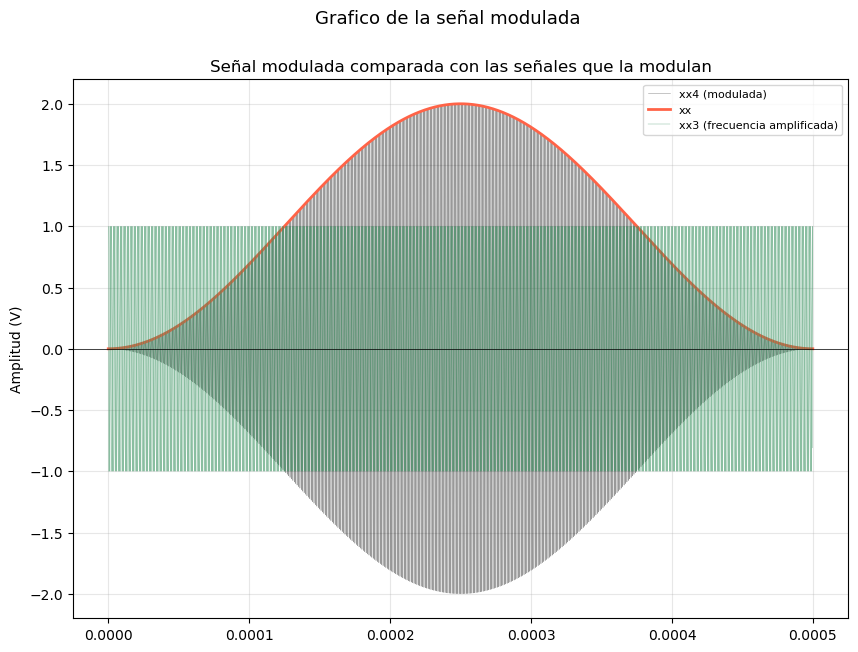

In [142]:
xx4 = (xx3) * (xx + vmax) 
#se le suma vmax a xx para que se genere de manera correcta el batido (debo elevar en el eje y a mi funcion xx para que no exista parte negativa)
tt4 = tt2

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Grafico de la señal modulada', fontsize=13)


ax1.plot(tt4, xx4,  color='black', linewidth=0.4,   alpha=0.4, label='xx4 (modulada)')
ax1.plot(tt, xx + vmax, color='tomato',    linewidth=2, label='xx')
ax1.plot(tt3, xx3, color='seagreen',    linewidth=0.2, label='xx3 (frecuencia amplificada)')
ax1.set_ylabel('Amplitud (V)')
ax1.set_title('Señal modulada comparada con las señales que la modulan')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)

In [143]:
print('Período: ', 1/f0) #en f0 es cuando vuelven a estar en fase xx y xx3
print('Período de muestreo: ', 1/fs)
print('Número de muestras: ', n)
print('Potencia de la señal: ', (vmax**2 + np.mean(xx**2))/2)

Período:  0.0005
Período de muestreo:  1e-07
Número de muestras:  5000
Potencia de la señal:  0.75


Como podemos observar en el gráfico, la función xx4 (señal modulada) es un batido generado por la señal original y la de frecuencia amplificada. 

Notamos que su amplitud máxima oscila teniendo como limite superior a xx, y como límite inferior a -xx. Además, aunque quizá no se puede apreciar correctamente en el gráfico, la frecuencia de las oscilaciones es igual a la de la señal de frecuencia amplificada.

***Inciso 4***

Para este inciso, nuestro objetivo es generar una señal igual a la original, pero con efecto de saturación al 75% de su amplitud.

¿Qué es el efecto de saturación? Esto significa que la amplitud de la señal supera la amplitud máxima que se puede manejar(o en nuestro caso, que se quiere manejar). Por lo tanto, si buscamos un efecto de saturación al 75% de la amplitud, buscamos que cuando la amplitud de la señal original llegue al 75% de su valor máximo, se recorte, generando que los picos estén recortados.

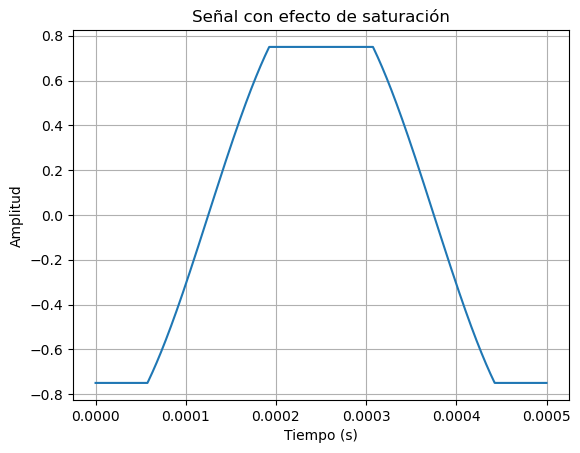

In [144]:
'Generamos la señal recortada usando np.clip'

xx5 = np.clip(xx, (-0.75 * vmax), (0.75) * vmax)
tt5 = tt

plt.plot(tt5, xx5)
plt.title("Señal con efecto de saturación")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

In [145]:
print('Período: ', 1/f0)
print('Período de muestreo: ', 1/fs)
print('Número de muestras: ', n)
print('Potencia de la señal: ', np.mean(xx5**2))

Período:  0.0005
Período de muestreo:  1e-07
Número de muestras:  5000
Potencia de la señal:  0.3708500576401642


Tal y como esperábamos, la señal obtenida es igual a la original, pero con los picos recortados en 0.75 (ya que nuestra amplitud máxima es de 1).

A contnuación, podemos ver ambas señales juntas, lo que nos permitirá ver bien lo hecho en la función recortada.

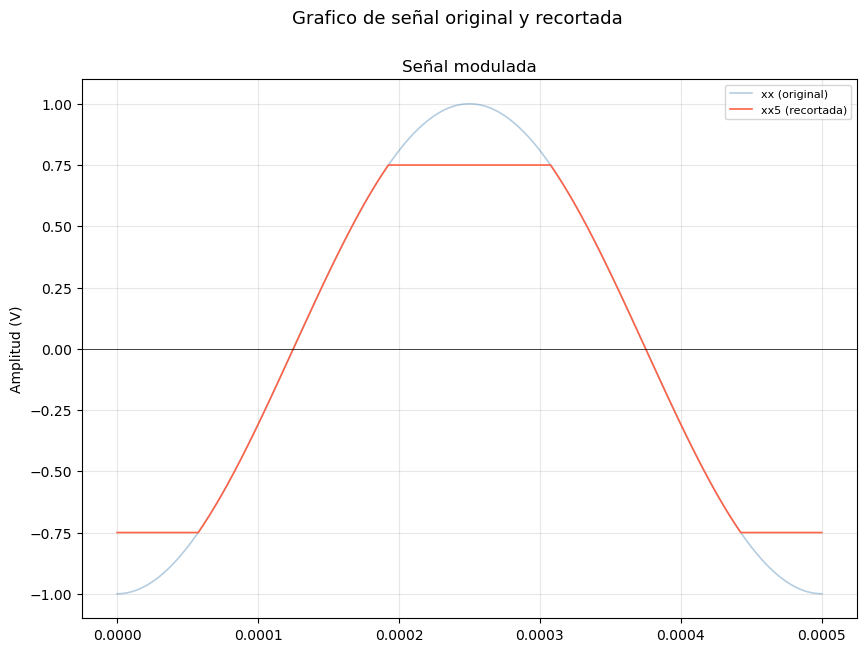

In [146]:
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Grafico de señal original y recortada', fontsize=13)


ax1.plot(tt, xx,  color='steelblue', linewidth=1.2,   alpha=0.4, label='xx (original)')
ax1.plot(tt5, xx5, color='tomato',    linewidth=1.2, label='xx5 (recortada)')
ax1.set_ylabel('Amplitud (V)')
ax1.set_title('Señal modulada')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)

***Inciso 5***

En este inciso, buscamos gnerar una señal cuadrada con una frecuencia de 4kHz = 4000Hz.

Existen muchas formas de generar una señal cuadrada, sin embargo la más sencilla es utilizar una señal igual a la original que ya tenemos, cambiando la frecuencia,  y evaluar sus puntos: los positivos los igualamos a vmax y los negativos a -vmax. Esto lo podemos hacer sin problema con la función np.where.

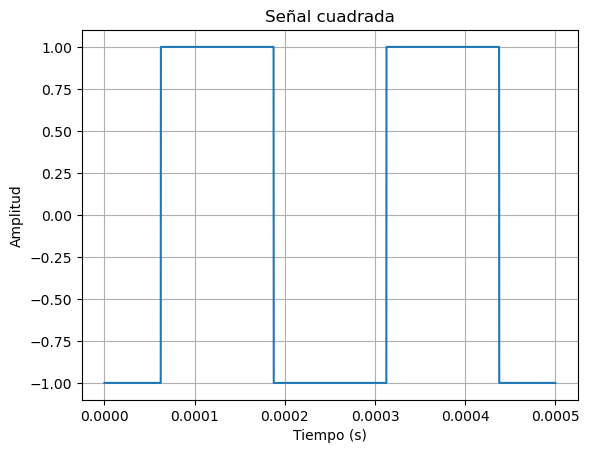

In [147]:
f06 = 4000

tt6, xx6 = mi_funcion_sen(vmax, dc, f06, ph, n, fs)

xx_cuadrada = np.where(xx6 >= 0, vmax, -vmax)
tt_cuadrada = tt6

plt.plot(tt_cuadrada, xx_cuadrada)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

In [148]:
print('Período: ', 1/f06)
print('Período de muestreo: ', 1/fs)
print('Número de muestras: ', n)
print('Potencia de la señal: ', vmax**2)

Período:  0.00025
Período de muestreo:  1e-07
Número de muestras:  5000
Potencia de la señal:  1


De esta manera, obtenemos una señal cuadrada con amplitud igual a la original y la frecuencia deseada.

***Inciso 6***

Para este último inciso del ejercicio 1, buscamos generar un pulso cuadrado. Este, a diferencia de en el caso anterior, no se repite de manera periódica sino que es único en el tiempo.

¿Cómo generamos esto? La manera más sencilla es nuevamente utilizando la función np.where, seleccionando los instantes de tiempo en los que deseo que esté.

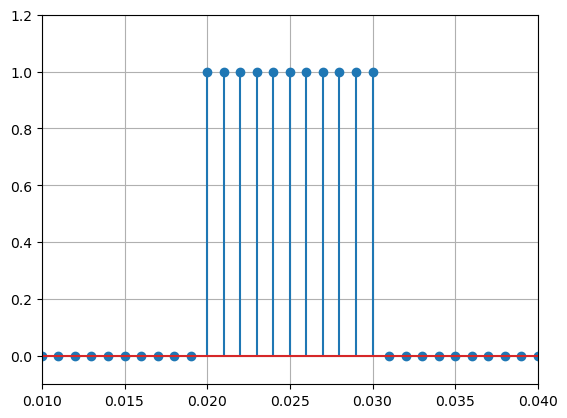

In [149]:
tt_amplitud = 10e-3
n_pulso = 1000
fs_pulso = 1000

tt_pulso = np.arange(n_pulso) / fs_pulso

xx_pulso = np.where((tt_pulso >= 0.02) & (tt_pulso <= 0.03), 1, 0)
#Comienzo en 0.02 para que se pueda ver bien

plt.figure()
plt.stem(tt_pulso, xx_pulso)
plt.xlim(0.01, 0.04)
plt.ylim(-0.1, 1.2)
plt.grid(True)
plt.show()

In [150]:
# En este caso no hay período ya que el pulso es único en el tiempo
print('Período de muestreo: ', 1/fs_pulso)
print('Número de muestras: ', n_pulso)
print('Energía del pulso: ', np.sum(xx_pulso**2) * (1/fs_pulso))
#Al ser un pulso en lugar de algo periódico en el tiempo, calculamos la energía en lugar de la potencia

Período de muestreo:  0.001
Número de muestras:  1000
Energía del pulso:  0.011


A diferencia de en los casos anteriores, en este caso se puede ver el valor en cada paso en lugar de una función generada en base a estos datos ya que considero que de esta manera se puede apreciar de manera más precisa la naturaleza del pulso.

***Conclusión***

A lo largo de este primer ejercicio, trabajamos con una señal base y aplicamos distintas transformaciones sobre ella para obtener los resultados buscados.

En este primer ejercicio, logramos amplificar y defasar una función a gusto, usarla para modular una función de frecuencia mucho mayor, generar un efecto de saturación, además de generar señales cuadradas y pulsos rectangulares. Estos conceptos son esenciales para entender cómo se comportan las señales reales en sistemas con limitaciones físicas, como la saturación por capacidad máxima del sistema.

### Ejercicio 2

El objetivo de este ejercicio es calcular la convolución de distintas señales tanto generandolas en python como manualmente.

Comenzamos definiendo las funciones que vamos a utilizar a lo largo de los tres incizos:

In [151]:
#Definimos la función delta
def delta(n):
    return np.where( n == 0, 1, 0)

def h(n):
    return delta(n) - delta(n - 4)

Teniendo h[n], buscamos calcular y[n] = x[n] * h[n] para los siguietes casos:
- x[n] = cos(ω₀.n. TS).
- x[n] = (1/2)ⁿ u[n].
- x[n] = u[n + 1] - u[n - 2].

<div style="text-align: middle;">
  <img src="JustificacionPrevia_TS1.jpg" width="1000">
</div>

Para los tres incisos, inicialmente se realizaron los cálculos en papel, lo que nos permite estimar el resultado que luego obtendremos en python, además de poder comprender el por qué de estos resultados.

***Incizo 1***

<div style="text-align: middle;">
  <img src="Ejercicio1_TS1.jpg" width="1000">
</div>

Comprobamos los resultados obtenidos en papel probandolos en python:

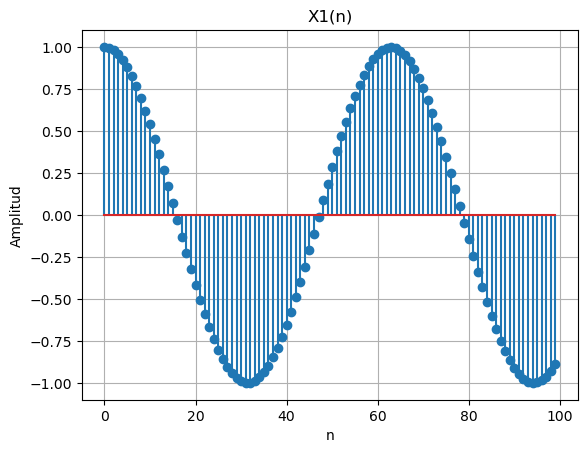

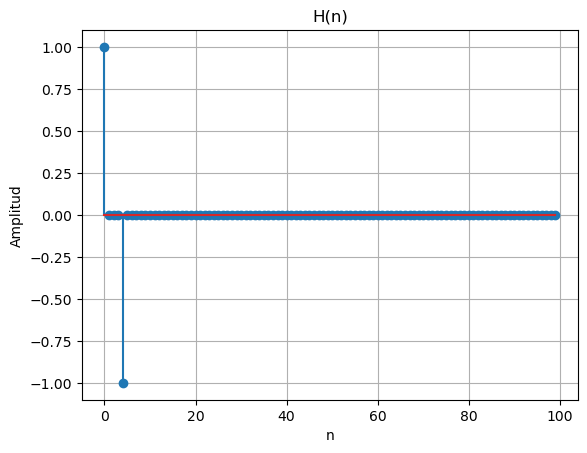

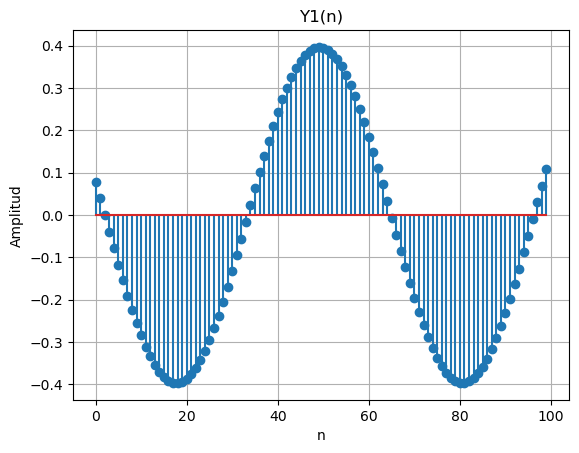

In [152]:
# Estos parámetros no son fijos, podrían valer otra cosa, especialmente w
w = 0.1 
Ts = 1

def x1(n):
    return np.cos(w * Ts * n)

def y1(n):
    return x1(n) - x1(n - 4)

n = np.arange(0, 100)

# Calculamos los arrays
#Esto se hace ya que debido a la manera en la que están definidas las funciones, para poder graficar todo correctamente es necesario crearlos
x1_arr = x1(n)
h_arr  = np.array([h(k) for k in n])   # h no es vectorizada, necesita loop
y1_arr = y1(n)

# Graficamos x1
plt.stem(n, x1_arr)
plt.title("X1(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Graficamos h
plt.stem(n, h_arr)
plt.title("H(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Graficamos y1
plt.stem(n, y1_arr)
plt.title("Y1(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Como podemos ver, tal como lo que esperábamos en lo calculado en papel, y1 tiene la misma freciencia que x1, sin embargo su amplitud cambia (depende del valor de w, como se mencionó en papel, esta convolución funciona como un filtro pasa altos) y también lo hace su fase.

***Incizo 2***

<div style="text-align: middle;">
  <img src="Ejercicio2_TS1.jpg" width="1000">
</div>

Con las predicciones ya hechas, evaluemos la convolución para observar los resultados obtenidos.

In [153]:
def u(n):
    return np.where(n >= 0, 1, 0)

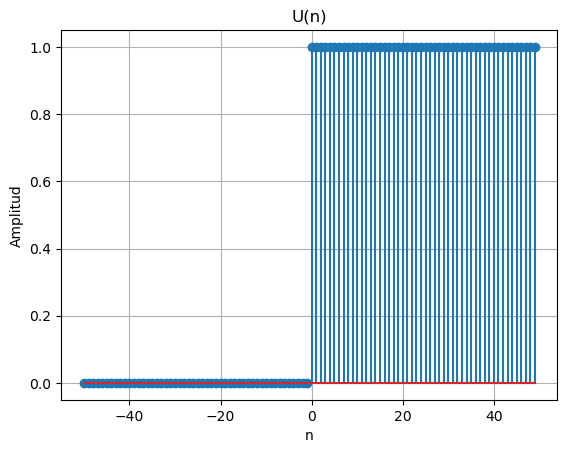

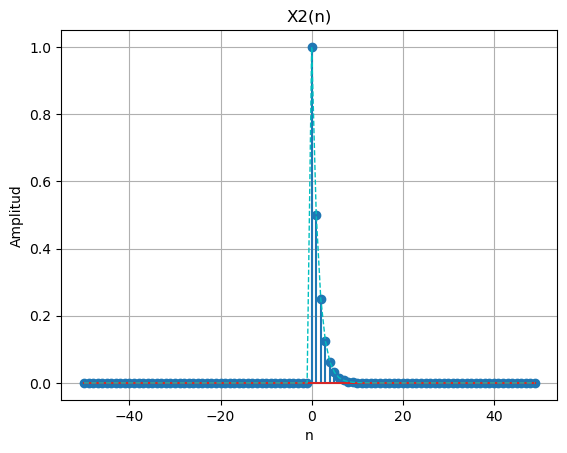

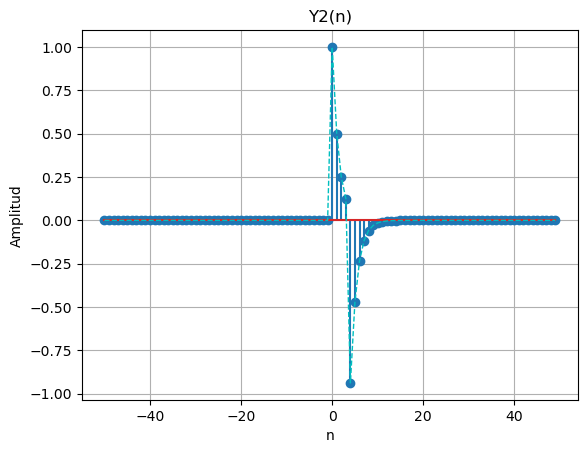

In [154]:
# Calculamos convolución del segundo punto
def x2(n):
    return ((1/2)**n) * u(n)

def y2(n):
    return x2(n) - x2(n-4)

n = np.arange(-50, 50)

# Calculamos los arrays
u_arr  = u(n)
x2_arr = x2(n)
y2_arr = y2(n)

# Graficamos u
plt.stem(n, u_arr)
plt.title("U(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Graficamos x2
plt.stem(n, x2_arr)
plt.plot(n, x2_arr, 'c--', linewidth= 1)
plt.title("X2(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Graficamos y2
plt.stem(n, y2_arr)
plt.plot(n, y2_arr, 'c--', linewidth= 1)
plt.title("Y2(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Como podemos observar, al igual que en lo predicho en papel, y2 tiene un comportamiento del tipo 1/2**n multiplicado por el valor de u(n) y u(n-4) respectivamente lo cual es equivalente a escalarlo (en algunos momentos por 0, en otros por 1 y en otros por -15).

***Incizo 3***

<div style="text-align: middle;">
  <img src="Ejercicio3_TS1.jpg" width="1000">
</div>

Revisamos estos resultados obtenidos, comparandolos con los obtenidos de manera digital.

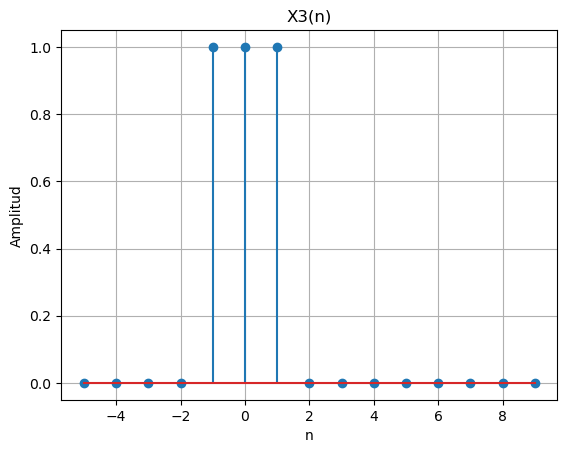

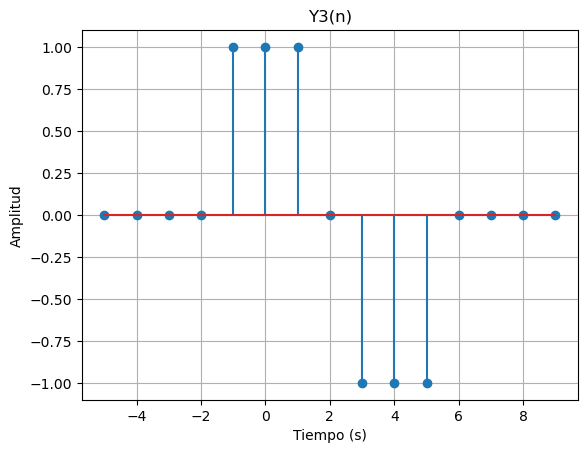

In [155]:
def x3(n):
    return u(n+1) - u(n-2)

def y3(n):
    return x3(n) - x3(n-4)

n = np.arange(-5, 10)

x3_arr = x3(n)
y3_arr = y3(n)

plt.stem(n, x3_arr)
plt.title("X3(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

plt.stem(n, y3_arr)
plt.title("Y3(n)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Como podemos observar, los resultados obtenidos son iguales a los esperados en base a los calculos hechos.

***Conclusión***

Podemos observar como en cada caso la convolución de la función con h(n) la afectó de manera particular, sin embargo con muchas similitudes, especialmente entre la segunda y la tercera.

En la primera, notamos que la diferencia entre x1 e y1 radica principalmente en el valor que nosotros elegimos para la velocidad angular, por lo que si elijeramos un w distinto podriamos observar otra amplitud en y1.

Tanto en el segundo caso como en el tercero, aunque son distintos, notamos como la convolución con h generó una función que produce dos copias de x separadas 4 muestras (una por cada delta de h, en n=0 y n=4) y las resta entre sí. Cada caso fue distinto ya que en el segundo se estaba trabajando con una función exponencial, en cambio en el tercero trabajamos con un pulso rectangular (notemos entonces como ésta podría haber sido otra manera de generar nuestra función pulso rectangular del ejercicio 1 inciso 6).

Podemos ver que el comportamiento general de el caso 2 y 3 es, sin embargo, bastante parecido. La razón de que el primer caso sea diferente se debe a su naturaleza como función periódica en el tiempo, por lo que incluso si se espejara en dos puntos distintos (en donde estén las deltas de h), el resultado no sería como el visto en los otros casos. Además, al hacer la convolución, la amplitud resultante depende de cuánto desfasaje introduce ese retardo de 4 muestras relativo al período (x[n-4])